In [2]:
from pathlib import Path
import numpy as np
import rasterio as rio
from tqdm import tqdm

GT_DIR = Path("/content/drive/MyDrive/GEE_Exports")
gt_files = sorted(GT_DIR.glob("unet_mt_2023_gtv2_*.tif"))
print("GT files:", len(gt_files))

hits = []
for p in tqdm(gt_files):
    with rio.open(p) as ds:
        # lê só a banda 1 (gt_train) para acelerar
        b = ds.read(1)
    c1 = int((b == 1).sum())
    c0 = int((b == 0).sum())
    c255 = int((b == 255).sum())
    if c1 > 0:
        hits.append((p.name, c1, c0, c255))

print("tiles com classe 1:", len(hits))
print("top 10 por count1:")
for row in sorted(hits, key=lambda x: x[1], reverse=True)[:10]:
    print(row)

GT files: 169


100%|██████████| 169/169 [00:23<00:00,  7.06it/s]

tiles com classe 1: 31
top 10 por count1:
('unet_mt_2023_gtv2_x-58p00_y-14p00.tif', 52351, 95180, 13627701)
('unet_mt_2023_gtv2_x-57p00_y-13p00.tif', 52042, 33875, 13693027)
('unet_mt_2023_gtv2_x-57p00_y-12p00.tif', 34883, 29243, 13711106)
('unet_mt_2023_gtv2_x-59p00_y-13p00.tif', 33310, 22358, 13723276)
('unet_mt_2023_gtv2_x-59p00_y-14p00.tif', 26347, 15173, 13737424)
('unet_mt_2023_gtv2_x-56p00_y-14p00.tif', 25339, 20589, 13733016)
('unet_mt_2023_gtv2_x-55p00_y-12p00.tif', 25217, 5773, 13740531)
('unet_mt_2023_gtv2_x-58p00_y-13p00.tif', 23047, 32728, 13719457)
('unet_mt_2023_gtv2_x-58p00_y-15p00.tif', 21975, 11692, 13737854)
('unet_mt_2023_gtv2_x-57p00_y-14p00.tif', 21203, 14589, 13743152)


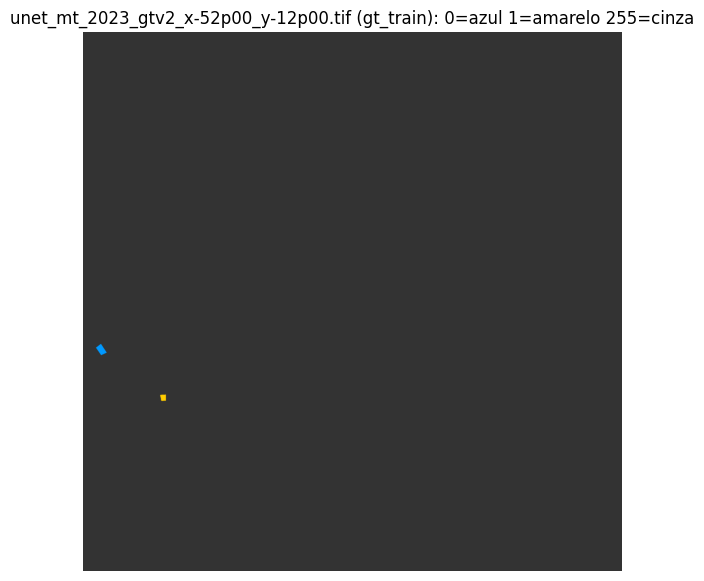

counts: {0: 2897, 1: 1526, 255: 13767098}


In [3]:
import matplotlib.pyplot as plt

# cole aqui o nome de um tile da lista hits:
NAME = hits[0][0] if hits else "unet_mt_2023_gtv2_x-56p00_y-14p00.tif"
p = GT_DIR / NAME

with rio.open(p) as ds:
    gt = ds.read(1)  # gt_train

mask0 = (gt == 0)
mask1 = (gt == 1)
maskI = (gt == 255)

vis = np.zeros((gt.shape[0], gt.shape[1], 3), dtype=np.float32)
vis[maskI] = (0.2, 0.2, 0.2)   # ignore = cinza
vis[mask0] = (0.0, 0.6, 1.0)   # classe 0 = azul
vis[mask1] = (1.0, 0.8, 0.0)   # classe 1 = amarelo

plt.figure(figsize=(7,7))
plt.imshow(vis)
plt.title(NAME + " (gt_train): 0=azul 1=amarelo 255=cinza")
plt.axis("off")
plt.show()

print("counts:", {0:int(mask0.sum()), 1:int(mask1.sum()), 255:int(maskI.sum())})

In [4]:
# CÉLULA 2 — ler metadados (crs, shape, transform) + checar bands
with rio.open(gt_path) as ds:
    print("driver:", ds.driver)
    print("crs:", ds.crs)
    print("shape (h,w):", (ds.height, ds.width))
    print("count bands:", ds.count)
    print("dtype:", ds.dtypes)
    print("transform:", ds.transform)
    print("bounds:", ds.bounds)

    # lê as 3 bandas
    arr = ds.read()  # (bands, h, w)

print("array shape:", arr.shape)
assert arr.shape[0] in (1,3), "esperava 3 bandas (gt_train/gt_test/gt_val) ou 1 banda"

NameError: name 'gt_path' is not defined

In [3]:
# CÉLULA 3 — contagem de valores (0/1/255) por banda
def count_vals(band):
    # band: (h,w) uint8
    u, c = np.unique(band, return_counts=True)
    d = dict(zip(u.tolist(), c.tolist()))
    total = band.size
    out = {
        "count0": d.get(0, 0),
        "count1": d.get(1, 0),
        "count255": d.get(255, 0),
        "other": total - d.get(0,0) - d.get(1,0) - d.get(255,0),
        "unique": d
    }
    out["frac1"] = out["count1"] / total
    out["frac255"] = out["count255"] / total
    return out

if arr.shape[0] == 1:
    stats = count_vals(arr[0])
    print("band 1 stats:", stats)
else:
    names = ["gt_train","gt_test","gt_val"]
    for i, nm in enumerate(names):
        st = count_vals(arr[i])
        print(f"{nm}: count0={st['count0']} count1={st['count1']} count255={st['count255']} other={st['other']}")
        print(f"    frac1={st['frac1']:.6f} frac255={st['frac255']:.6f} unique_keys={sorted(st['unique'].keys())}")

gt_train: count0=3712 count1=0 count255=13775232 other=0
    frac1=0.000000 frac255=0.999731 unique_keys=[0, 255]
gt_test: count0=3712 count1=0 count255=13775232 other=0
    frac1=0.000000 frac255=0.999731 unique_keys=[0, 255]
gt_val: count0=3712 count1=0 count255=13775232 other=0
    frac1=0.000000 frac255=0.999731 unique_keys=[0, 255]


In [4]:
# CÉLULA 4 — diagnóstico rápido (o que é OK vs problema)
def diagnose(st):
    keys = set(st["unique"].keys())
    if keys == {0}:
        return "PROBLEMA: só 0 (era esperado 255 fora dos polígonos)."
    if 255 not in keys:
        return "PROBLEMA: não tem 255 (fora dos polígonos deveria ser 255)."
    if keys.issubset({255}):
        return "OK: tile sem polígonos (tudo 255)."
    if keys.issubset({0,255}) and st["count1"] == 0:
        return "OK: tile tem polígonos apenas classe 0 (e 255 fora)."
    if keys.issubset({0,1,255}) and st["count1"] > 0:
        return "OK: tem classe 1 presente."
    if st["other"] > 0:
        return "ALERTA: tem valores além de 0/1/255."
    return "OK/ALERTA: caso não previsto."

if arr.shape[0] == 1:
    st = count_vals(arr[0])
    print(diagnose(st))
else:
    for i, nm in enumerate(["gt_train","gt_test","gt_val"]):
        st = count_vals(arr[i])
        print(nm, "->", diagnose(st))

gt_train -> OK: tile tem polígonos apenas classe 0 (e 255 fora).
gt_test -> OK: tile tem polígonos apenas classe 0 (e 255 fora).
gt_val -> OK: tile tem polígonos apenas classe 0 (e 255 fora).


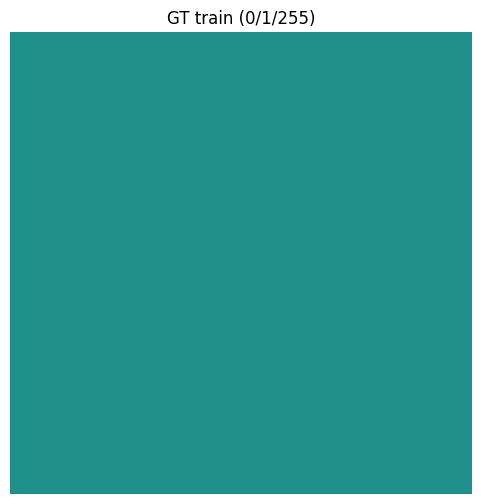

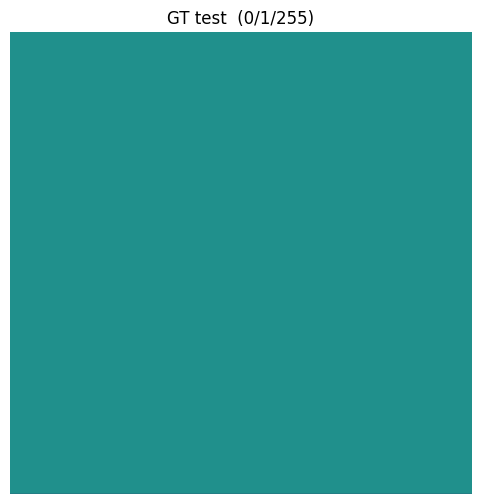

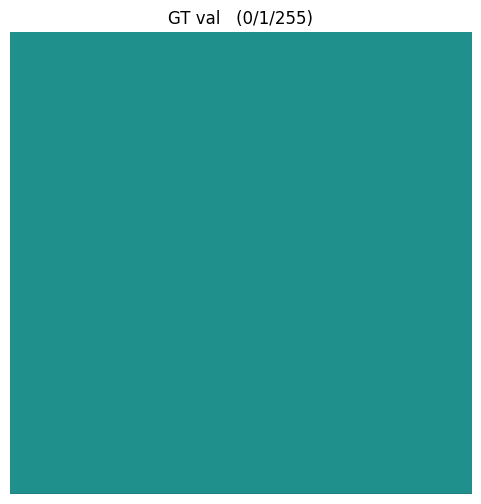

In [5]:
# CÉLULA 5 — viewer simples (RGB falso: 1=branco, 0=preto, 255=cinza)
import matplotlib.pyplot as plt

def show_band(band, title):
    # mapeia: 255->0.5, 1->1.0, 0->0.0
    vis = band.astype(np.float32)
    vis[vis == 255] = 128
    vis = vis / 255.0
    plt.figure(figsize=(6,6))
    plt.imshow(vis, vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.show()

if arr.shape[0] == 1:
    show_band(arr[0], "GT band")
else:
    show_band(arr[0], "GT train (0/1/255)")
    show_band(arr[1], "GT test  (0/1/255)")
    show_band(arr[2], "GT val   (0/1/255)")

MOSAIC path: /content/drive/MyDrive/GEE_Exports/unet_mt_2023_mosaic_x-62p00_y-17p00.tif


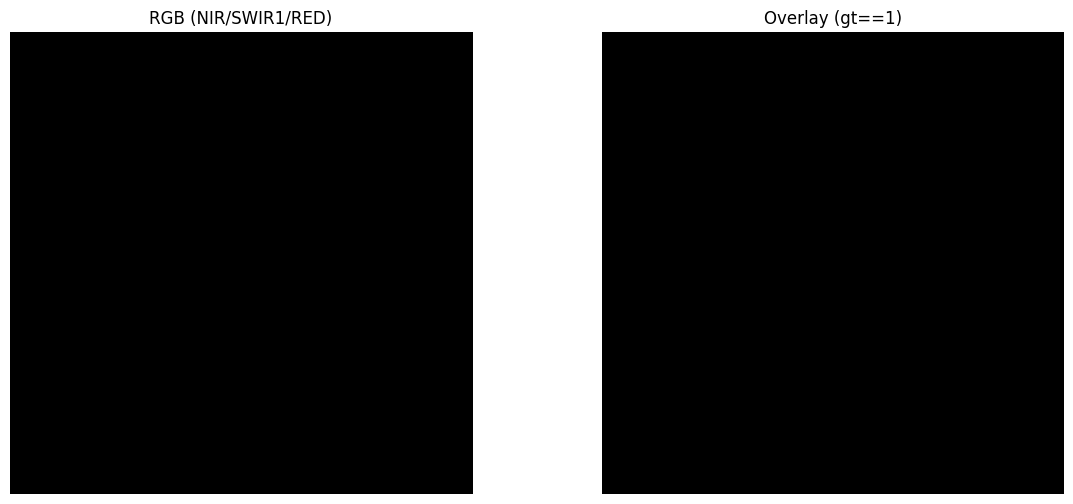

In [6]:
# CÉLULA 6 — (opcional) checar um mosaico correspondente e ver overlay rápido
# ajuste o mosaico correspondente (mesmo x/y)
MOSAIC_NAME = TILE_NAME.replace("gtv2_", "mosaic_").replace("gt_", "mosaic_")  # tenta inferir
mosaic_path = LOCAL_DIR / MOSAIC_NAME
if not mosaic_path.exists():
    mosaic_path = DRIVE_EXPORTS / MOSAIC_NAME

print("MOSAIC path:", mosaic_path)
if mosaic_path.exists():
    with rio.open(mosaic_path) as ds:
        X = ds.read([10, 13, 7])  # NIR_median (10), SWIR1_median (13), RED_median (7) -> confira se bater
        X = np.transpose(X, (1,2,0)).astype(np.float32) / 10000.0  # u16 -> 0-1
    # overlay: pinta milho (1) em amarelo por cima
    gt_any = arr[0] if arr.shape[0] == 1 else arr[0]  # usa train para visualizar
    mask1 = (gt_any == 1)

    rgb = np.clip(X, 0, 1)
    overlay = rgb.copy()
    overlay[mask1, 0] = 1.0
    overlay[mask1, 1] = 1.0
    overlay[mask1, 2] = 0.0

    plt.figure(figsize=(14,6))
    plt.subplot(1,2,1); plt.imshow(rgb); plt.title("RGB (NIR/SWIR1/RED)"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(overlay); plt.title("Overlay (gt==1)"); plt.axis("off")
    plt.show()
else:
    print("não achei mosaico correspondente para overlay (ok).")